# 01 – Dataset Exploration

This notebook provides a first overview of the MUSDB18 dataset.

Goals:
- inspect the train/test split
- calculate track durations
- verify sample rate and channel structure
- summarize basic dataset statistics
- visualize the distribution of track lengths

Imports

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import stempeg

Paths

In [4]:
PROJECT_ROOT = Path.cwd().parent

TRAIN_DIR = PROJECT_ROOT / "data" / "raw" / "train"
TEST_DIR = PROJECT_ROOT / "data" / "raw" / "test"

train_files = sorted(TRAIN_DIR.glob("*.mp4"))
test_files = sorted(TEST_DIR.glob("*.mp4"))

print(f"Train tracks: {len(train_files)}")
print(f"Test tracks:  {len(test_files)}")

Train tracks: 100
Test tracks:  50


To prevent a bug in the "read_stems" function

In [7]:
import warnings

warnings.warning = warnings.warn

Function for getting info about stems

In [8]:
def get_track_info(file_path, split):
    stems, sample_rate = stempeg.read_stems(str(file_path))

    mixture = stems[0]

    duration_seconds = mixture.shape[0] / sample_rate
    channels = mixture.shape[1]

    return {
        "track": file_path.stem,
        "split": split,
        "duration_seconds": duration_seconds,
        "sample_rate": sample_rate,
        "channels": channels,
    }

The whole data set infos

In [9]:
rows = []

for file_path in train_files:
    rows.append(get_track_info(file_path, "train"))

for file_path in test_files:
    rows.append(get_track_info(file_path, "test"))

df = pd.DataFrame(rows)

df.head()

c:\Users\lithv\miniconda3\Lib\site-packages\stempeg\read.py:290: UserWarning: Stems differ in length and were shortend
  warnings.warning("Stems differ in length and were shortend")


,track,split,duration_seconds,sample_rate,channels
0,A Classic Education - NightOwl.stem,train,171.240000,44100,2
1,Actions - Devil's Words.stem,train,196.607937,44100,2
2,Actions - One Minute Smile.stem,train,163.371995,44100,2
3,Actions - South Of The Water.stem,train,176.602993,44100,2
4,Aimee Norwich - Child.stem,train,189.069683,44100,2


In [10]:
print(f"Total tracks: {len(df)}")
print(f"Average duration: {df['duration_seconds'].mean():.2f} s")
print(f"Shortest track: {df['duration_seconds'].min():.2f} s")
print(f"Longest track: {df['duration_seconds'].max():.2f} s")

total_hours = df["duration_seconds"].sum() / 3600
print(f"Total dataset duration: {total_hours:.2f} h")

Total tracks: 150
Average duration: 235.53 s
Shortest track: 12.89 s
Longest track: 628.36 s
Total dataset duration: 9.81 h


Sample rate/Stereo

In [11]:
print("Sample rates:")
print(df["sample_rate"].value_counts())

print("\nChannels:")
print(df["channels"].value_counts())

Sample rates:
sample_rate
44100    150
Name: count, dtype: int64

Channels:
channels
2    150
Name: count, dtype: int64


Visualization of the track length 

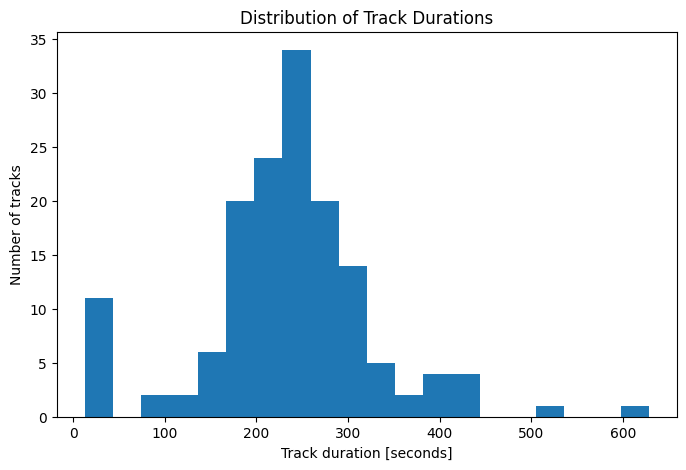

In [12]:
plt.figure(figsize=(8, 5))
plt.hist(df["duration_seconds"], bins=20)

plt.xlabel("Track duration [seconds]")
plt.ylabel("Number of tracks")
plt.title("Distribution of Track Durations")

plt.show()

Train & Test Comparison

In [13]:
df.groupby("split")["duration_seconds"].agg(
    ["count", "mean", "min", "max"]
)

,count,mean,min,max
split,,,,
test,50,249.219756,75.995964,430.175011
train,100,228.685871,12.890998,628.358005


## Observations

- MUSDB18 contains 100 training tracks and 50 test tracks.
- All tracks use a sampling rate of 44.1 kHz.
- All signals are stereo.
- Track durations vary, but the dataset consists mainly of full-length songs.
- The dataset is already well structured and requires little classical preprocessing.